## Simple Linear Regression

In [2]:
# importing some important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#getting the data

df = pd.read_csv('Datasets/height-weight.csv')


In [4]:
df.head(2)

,Weight,Height
0,45,120
1,58,135


Text(0, 0.5, 'Weight')

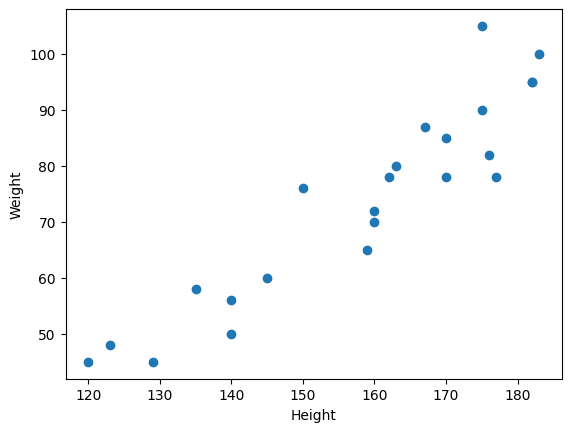

In [8]:
# see the data 
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')

In [7]:
# correlation between height and weight
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


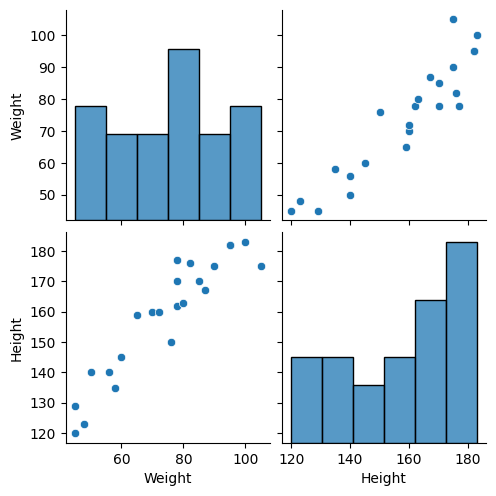

In [9]:
import seaborn as sns
sns.pairplot(df)

It is linearly correlated. So got good feeling that simple linear regression will work.

In [10]:
## Independent and dependent features
X = df[['Weight']]  # Independent feature should be data frame or 2 dimensional array
y = df['Height'] # Dependent feature should be a series or 1 dimentional array

In [17]:
## Train test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=42)

In [ ]:
X_train.shape #should be 2 dimentional array

(17, 1)

In [19]:
## Standarization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# we only need to standradize the independent features not the dependent features
# bcz our gradient descent is applied only on the independent features

X_train= scaler.fit_transform(X_train)

In [20]:
X_test = scaler.transform(X_test) 

In [21]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [22]:
# Apply Simple Linear Regression

from sklearn.linear_model import LinearRegression

In [23]:
regressor = LinearRegression()

In [24]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
regressor.coef_ # this is the slope of the line

array([17.2982057])

In [27]:
print('Coefficient: ', regressor.coef_)
print('Intercept: ', regressor.intercept_)

Coefficient:  [17.2982057]
Intercept:  156.47058823529412


Text(0, 0.5, 'Height')

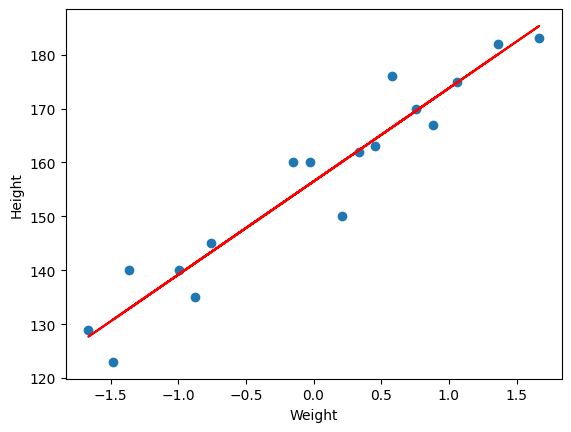

In [29]:
# plot best fit line with respect to training data
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), color='red')
plt.xlabel('Weight')
plt.ylabel('Height')

# prediction of test data
predicted_height_output = intercept + coef_(Weights)

y_pred_test = 156.470 + 17.29 (X_test)

In [31]:
# prediction for test data
y_pred = regressor.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [34]:
# Performance metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mse)
print(mae)
print(rmse)
print(r2)

114.84069295228699
9.66512588679501
10.716374991212605
0.7360826717981276


## Adjusted R2_Score

Adjusted R2 = 1-[(1-R2)*(n-1)(n-k-1)]

where:
- R2 is R2 of the model
- n is the number of observations
- k is the number of predictor variables

In [36]:
# adjusted r2 score

1-(1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [40]:
# OLS linear regression
!pip install statsmodels
import statsmodels.api as sm

In [41]:
model = sm.OLS(y_train, X_train).fit()

In [42]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [43]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 11 Apr 2026   Prob (F-statistic):                       0.664
Time:                        04:18:00   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\codingprojects\MLAlgorithms\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [44]:
## prediction for new data

regressor.predict(scaler.transform([[72]]))

c:\codingprojects\MLAlgorithms\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])